## GMM Model Evaluation

In [18]:
from preprocessing import preprocess
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

X_scaled, scaler, df, feature_names = preprocess(return_df=True)
df_numeric = df[feature_names]

/Users/megan/Documents/Year 3/Games Project/Games Project Unity/ChronoQuest1/Assets/Scripts/Final Boss ML/preprocessing.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["dash_rate"] = df["dash_count"] / df["session_duration_seconds"]
/Users/megan/Documents/Year 3/Games Project/Games Project Unity/ChronoQuest1/Assets/Scripts/Final Boss ML/preprocessing.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["jump_rate"] = (df["jump_count"] + df["wall_jump_count"] + df["double_jump_count"]) / df["sessi

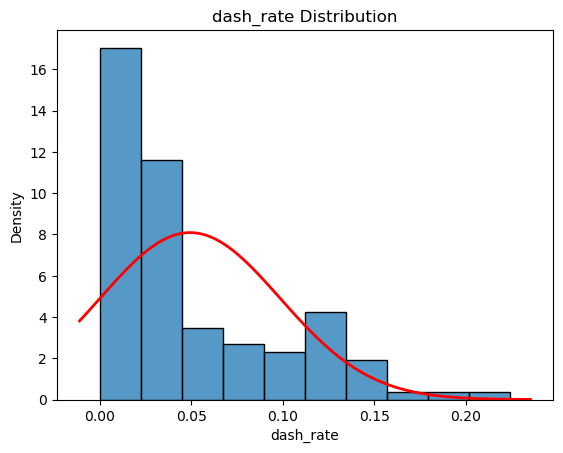

In [19]:
# --- histogram visualisation of dash feature ---
dash_feature = "dash_rate"
data = df_numeric[dash_feature] 

sns.histplot(data, kde=False, stat='density')
mu, std = norm.fit(data)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

plt.plot(x, p, 'r', linewidth=2)
plt.title(f"{dash_feature} Distribution")
plt.show()

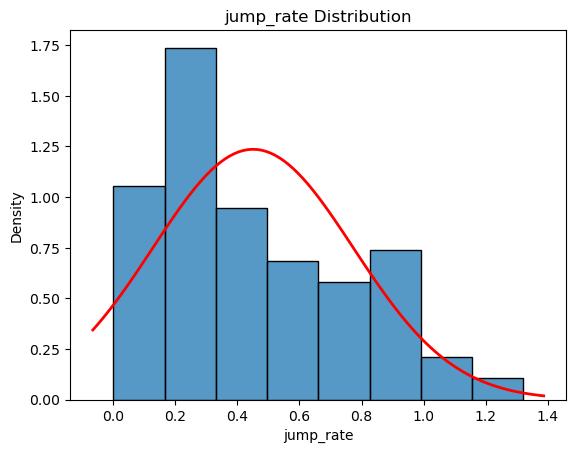

In [20]:
# --- histogram visualisation of jump feature ---
jump_feature = "jump_rate"
jump_data = df_numeric[jump_feature]

sns.histplot(jump_data, kde=False, stat='density')
mu, std = norm.fit(jump_data)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

plt.plot(x, p, 'r', linewidth=2)
plt.title(f"{jump_feature} Distribution")
plt.show()

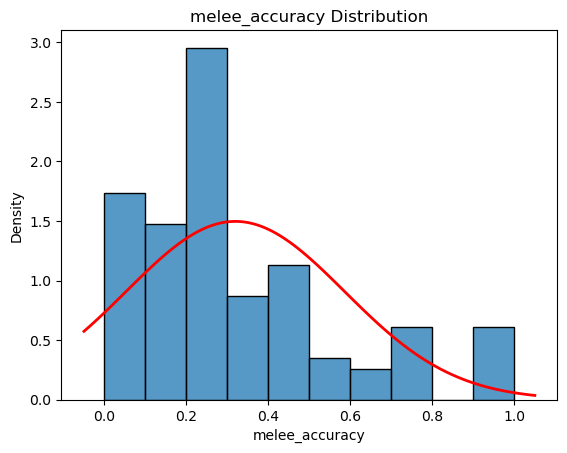

In [21]:
# --- melee feature histogram ---
melee_features = "melee_accuracy"
melee_data = df_numeric[melee_features]

sns.histplot(melee_data, kde=False, stat='density')
mu, std = norm.fit(melee_data)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

plt.plot(x, p, 'r', linewidth=2)
plt.title(f"{melee_features} Distribution")
plt.show()

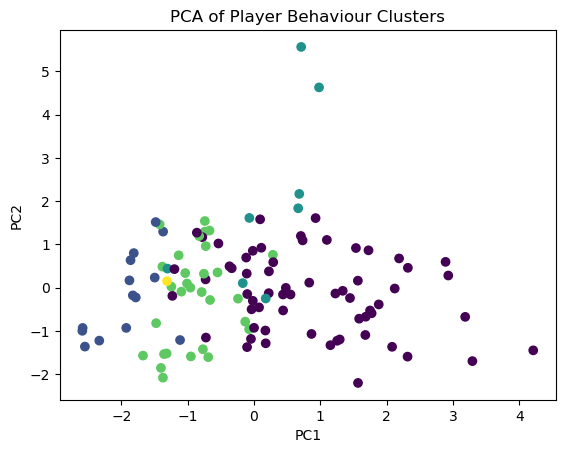

In [22]:
# --- pca for visualisation ---
gmm = GaussianMixture(n_components=5, random_state=42)
labels = gmm.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.title("PCA of Player Behaviour Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()